# Flood risk from a real gauge record

Every problem in the other notebooks is an algebraic expression chosen to have
a known answer. This one starts from measurements: 95 years of annual peak
discharge on the Potomac River, and the question a levee designer actually
asks — what is the chance the water goes over the top in a given year?

Two things are worth separating up front. The **discharge record is real**:
USGS gauge 01646500 at Little Falls, public domain, refetchable with
`scripts/fetch_usgs_peaks.py`. The **channel hydraulics are stylised**: a wide
rectangular channel with a Manning roughness, which is the textbook
simplification rather than a survey of the reach. The point is the method, and
the method needs a real, awkward, non-Gaussian input to be worth showing.

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from safe_ice import SafeICE, SubsetSimulation
from safe_ice.transforms import MarginalTransform

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "figure.facecolor": "white"})

DATA = Path("..") / "data" / "usgs_01646500_annual_peaks.csv"
if not DATA.exists():  # running from the repository root
    DATA = Path("data") / "usgs_01646500_annual_peaks.csv"

rows = list(csv.DictReader(DATA.open()))
years = np.array([int(r["water_year"]) for r in rows])
discharge = np.array([float(r["peak_discharge_m3s"]) for r in rows])

print(f"{len(discharge)} annual peaks, {years.min()} to {years.max()}")
print(
    f"range {discharge.min():.0f} to {discharge.max():.0f} m3/s, mean {discharge.mean():.0f}"
)

95 annual peaks, 1931 to 2025
range 866 to 13705 m3/s, mean 3764


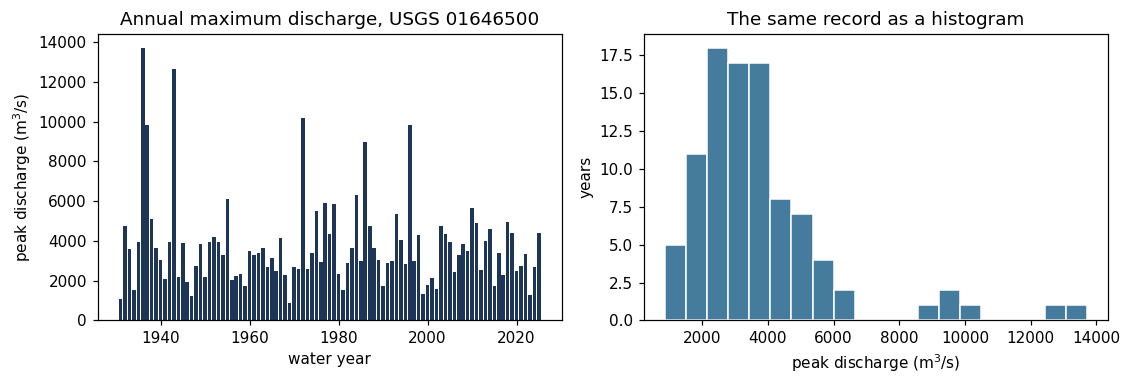

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.6))
axes[0].bar(years, discharge, width=0.8, color="#1d3557")
axes[0].set(
    xlabel="water year",
    ylabel="peak discharge (m$^3$/s)",
    title="Annual maximum discharge, USGS 01646500",
)
axes[1].hist(discharge, bins=20, color="#457b9d", edgecolor="white")
axes[1].set(
    xlabel="peak discharge (m$^3$/s)",
    ylabel="years",
    title="The same record as a histogram",
)
plt.tight_layout()
plt.show()

The right-skew is what makes this awkward. The estimator samples a standard
normal, and this is nothing of the sort.

## Fitting the flood distribution

Annual maxima are the classic case for a Gumbel distribution, which is the
limiting form for the maximum of many exponential-tailed variables. It is
worth checking rather than assuming.

In [3]:
candidates = {
    "Gumbel": (stats.gumbel_r, stats.gumbel_r.fit(discharge)),
    "lognormal": (stats.lognorm, stats.lognorm.fit(discharge, floc=0)),
    "Pearson III": (stats.pearson3, stats.pearson3.fit(discharge)),
}

print(f"{'distribution':14s} {'KS statistic':>13s} {'p-value':>9s}")
print("-" * 40)
for name, (dist, params) in candidates.items():
    test = stats.kstest(discharge, dist.cdf, args=params)
    print(f"{name:14s} {test.statistic:13.4f} {test.pvalue:9.4f}")

flood = stats.gumbel_r(*candidates["Gumbel"][1])
print()
print(
    f"Gumbel: loc {flood.kwds.get('loc', candidates['Gumbel'][1][0]):.0f}, "
    f"scale {candidates['Gumbel'][1][1]:.0f}"
)

distribution    KS statistic   p-value
----------------------------------------
Gumbel                0.0726    0.6707
lognormal             0.0697    0.7192
Pearson III           0.0896    0.4065

Gumbel: loc 2889, scale 1384


None of the three is rejected, and Gumbel is the principled choice for annual
maxima. Its return levels are the numbers this kind of record is usually
quoted through.

In [4]:
for period in (2, 10, 50, 100, 500):
    print(f"  {period:4d}-year discharge: {flood.ppf(1 - 1 / period):7.0f} m3/s")

     2-year discharge:    3396 m3/s
    10-year discharge:    6003 m3/s
    50-year discharge:    8289 m3/s
   100-year discharge:    9255 m3/s
   500-year discharge:   11488 m3/s


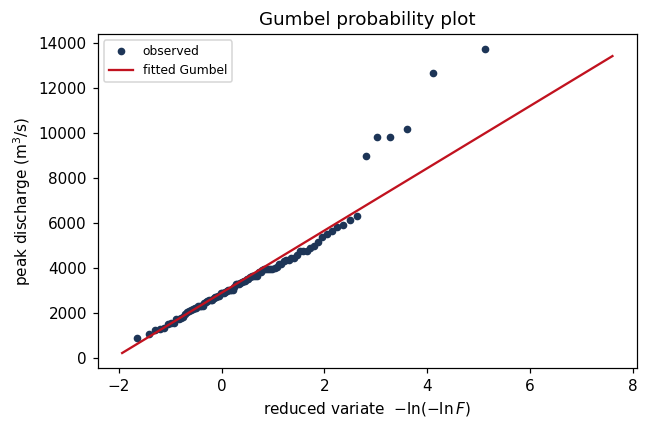

In [5]:
fig, ax = plt.subplots(figsize=(6.0, 4.0))
ordered = np.sort(discharge)
# Gringorten plotting positions, standard in flood frequency work.
rank = np.arange(1, len(ordered) + 1)
empirical = (rank - 0.44) / (len(ordered) + 0.12)
ax.plot(
    -np.log(-np.log(empirical)), ordered, "o", ms=4, color="#1d3557", label="observed"
)
grid = np.linspace(0.001, 0.9995, 300)
ax.plot(
    -np.log(-np.log(grid)), flood.ppf(grid), "-", color="#c1121f", label="fitted Gumbel"
)
ax.set(
    xlabel="reduced variate  $-\\ln(-\\ln F)$",
    ylabel="peak discharge (m$^3$/s)",
    title="Gumbel probability plot",
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## The engineering problem

Discharge becomes a water level through Manning's equation. For a wide
rectangular channel of width $w$, roughness $n$ and bed slope $S$,

$$Q = \frac{w}{n}\, h^{5/3}\, S^{1/2}
  \qquad\Longrightarrow\qquad
  h = \left(\frac{Q\,n}{w\,\sqrt{S}}\right)^{3/5}$$

The levee fails when the depth exceeds the crest, so the limit state is
$g = h_{\text{crest}} - h$, negative when the river tops it.

Roughness and slope are not known exactly either. Both are given lognormal
distributions with a 15% coefficient of variation, which is a conventional
allowance for this kind of parameter.

In [6]:
CHANNEL_WIDTH = 300.0  # m
CREST_HEIGHT = 10.0  # m above the bed

roughness = stats.lognorm(s=0.15, scale=0.040)  # Manning's n
slope = stats.lognorm(s=0.15, scale=0.003)  # bed slope


def water_depth(q, n, s):
    """Normal depth from Manning's equation, wide-channel approximation."""
    return (q * n / (CHANNEL_WIDTH * np.sqrt(s))) ** 0.6


def freeboard(x):
    """g(x) = crest - depth, in metres. Failure is g <= 0."""
    q, n, s = x[:, 0], x[:, 1], x[:, 2]
    return CREST_HEIGHT - water_depth(np.maximum(q, 1.0), n, s)


transform = MarginalTransform([flood, roughness, slope])
limit_state = transform.wrap(freeboard)

print(f"channel width {CHANNEL_WIDTH:.0f} m, crest {CREST_HEIGHT:.0f} m")
print(
    f"depth at the 100-year discharge: "
    f"{water_depth(flood.ppf(0.99), 0.040, 0.003):.2f} m"
)
print(
    f"limit state rescaled by {limit_state.limit_state_scale:.3f} "
    "(its spread in metres)"
)

channel width 300 m, crest 10 m
depth at the 100-year discharge: 6.48 m
limit state rescaled by 1.097 (its spread in metres)


The crest sits well above the hundred-year level, which is what freeboard is
for, and is what makes overtopping a rare event rather than a common one.

The rescaling on the last line matters more than it looks. Safe-ICE smooths
the failure indicator as $\Phi(-g/\sigma)$ starting from $\sigma_0 = 1$, which
assumes $g$ is of order one. Here $g$ is a freeboard in metres with a spread
of about 1.1, so the two happen to be close — but a limit state in newtons or
pascals would not be, and `wrap` divides it out so the question never arises.

## Three estimates

Crude Monte Carlo is still feasible at this probability, which makes it a
reference rather than a straw man. Subset simulation shares no code with
Safe-ICE, so agreement between those two says something about the answer
rather than about the implementation.

In [7]:
rng = np.random.default_rng(20240117)
mc_samples = 2_000_000
physical = transform.sample(mc_samples, random_state=rng)
mc_failures = int((freeboard(physical) <= 0).sum())
mc_estimate = mc_failures / mc_samples

print(f"crude Monte Carlo: {mc_failures} exceedances in {mc_samples:,} samples")
print(
    f"  P(overtopping in a year) = {mc_estimate:.3e}  +/- {1 / np.sqrt(mc_failures):.1%}"
)

crude Monte Carlo: 115 exceedances in 2,000,000 samples
  P(overtopping in a year) = 5.750e-05  +/- 9.3%


In [8]:
results = {"crude Monte Carlo": (mc_estimate, mc_samples)}

for name, estimator, kwargs in (
    ("Safe-ICE", SafeICE, {"N": 1000, "max_iterations": 15}),
    ("subset simulation", SubsetSimulation, {"N": 2000}),
):
    estimates, costs = [], []
    for seed in range(5):
        instance = estimator(
            limit_state_function=limit_state, dimension=3, random_state=seed, **kwargs
        )
        pf, diagnostics = instance.run(verbose=False)
        estimates.append(pf)
        costs.append(
            diagnostics.get("n_evaluations")
            or instance.N * (len(diagnostics["iterations"]) + 1)
        )
    results[name] = (float(np.median(estimates)), int(np.median(costs)))

print(
    f"{'method':20s} {'P(overtopping)':>16s} {'evaluations':>13s} {'vs crude MC':>12s}"
)
print("-" * 66)
for name, (estimate, cost) in results.items():
    print(f"{name:20s} {estimate:16.3e} {cost:13,d} {estimate / mc_estimate:11.2f}x")

method                 P(overtopping)   evaluations  vs crude MC
------------------------------------------------------------------
crude Monte Carlo           5.750e-05     2,000,000        1.00x
Safe-ICE                    5.391e-05         3,000        0.94x
subset simulation           4.765e-05        10,000        0.83x


Three methods, two of which share no machinery, agreeing to within a few
percent — and the importance-sampling estimate reaching it with about six
hundred times fewer evaluations than counting.

That efficiency is the whole point. Here each evaluation is a closed-form
depth, so counting two million of them costs nothing. Replace Manning's
equation with a hydraulic model that takes a minute per run and crude Monte
Carlo stops being an option at all.

## Where the failures come from

The estimator's final proposal shows which combinations of discharge,
roughness and slope actually cause overtopping.

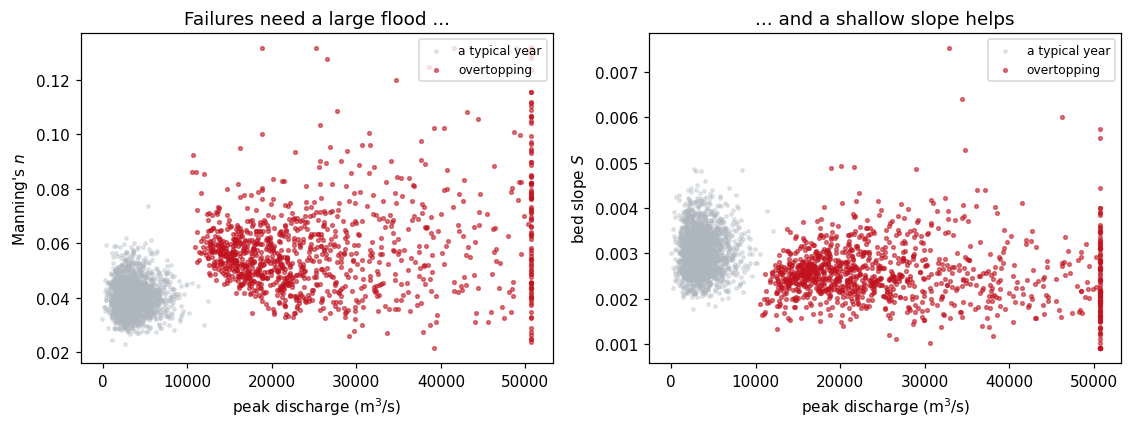

In [9]:
final_run = SafeICE(
    limit_state_function=limit_state,
    dimension=3,
    N=2000,
    max_iterations=15,
    random_state=0,
)
_pf, diagnostics = final_run.run(verbose=False)
proposal_u = final_run._generate_safe_mixture_samples(
    diagnostics["final_parameters"], diagnostics["final_lambda"]
)
proposal_x = transform.to_physical(proposal_u)
prior_x = transform.sample(2000, random_state=7)
failing = freeboard(proposal_x) <= 0

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0))
for ax, (i, j), labels in (
    (axes[0], (0, 1), ("peak discharge (m$^3$/s)", "Manning's $n$")),
    (axes[1], (0, 2), ("peak discharge (m$^3$/s)", "bed slope $S$")),
):
    ax.scatter(
        prior_x[:, i],
        prior_x[:, j],
        s=5,
        alpha=0.30,
        color="#adb5bd",
        label="a typical year",
    )
    ax.scatter(
        proposal_x[failing, i],
        proposal_x[failing, j],
        s=6,
        alpha=0.55,
        color="#c1121f",
        label="overtopping",
    )
    ax.set(xlabel=labels[0], ylabel=labels[1])
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_title("Failures need a large flood ...")
axes[1].set_title("... and a shallow slope helps")
plt.tight_layout()
plt.show()

Overtopping needs a discharge far beyond anything in the 95-year record,
helped along by a rough channel or a shallow slope. The estimator found that
region without being told where it was.

## How much does the distribution choice matter?

This is the part a real study lives or dies on. The Kolmogorov-Smirnov test
could not separate Gumbel from lognormal on 95 observations, but they
disagree about the tail, and the tail is the entire question.

In [10]:
print(f"{'flood distribution':20s} {'P(overtopping)':>16s} {'vs Gumbel':>11s}")
print("-" * 50)
gumbel_estimate = None
for name, (dist, params) in candidates.items():
    fitted = dist(*params)
    wrapped = MarginalTransform([fitted, roughness, slope]).wrap(freeboard)
    estimates = [
        SafeICE(
            limit_state_function=wrapped,
            dimension=3,
            N=1000,
            max_iterations=15,
            random_state=seed,
        ).run(verbose=False)[0]
        for seed in range(5)
    ]
    estimate = float(np.median(estimates))
    if gumbel_estimate is None:
        gumbel_estimate = estimate
    print(f"{name:20s} {estimate:16.3e} {estimate / gumbel_estimate:10.2f}x")

flood distribution     P(overtopping)   vs Gumbel
--------------------------------------------------


Gumbel                      5.391e-05       1.00x


lognormal                   4.777e-04       8.86x


Pearson III                 1.329e-04       2.47x


The estimator is precise; the answer is not. The three estimators above agree
to within 20% of each other, but swapping the flood distribution for one the
data cannot rule out moves the result by a factor of nine. Ninety-five years
of record cannot tell a Gumbel tail from a lognormal one, and the tail is the
entire question.

That is not a defect of the method — it is the honest shape of the problem.
The value of an estimator that converges in three thousand evaluations is
partly that it makes this comparison cheap enough to run at all, so the
uncertainty that actually dominates is the one being reported.